# 02 - Dataset Analysis (EDA)

Phân tích chi tiết annotation của `thermal-image-dataset`: số lượng object/ảnh, kích thước & vị trí bounding box, phân bố cường độ pixel.

Nguồn annotation: `Anotations/All_In_One_Anot_Yolo/` (bộ **All_In_One** - quyết định trong `configs/dataset.yaml`, KHÔNG dùng bộ "RGB" vì ít ảnh hơn: 4370/4402 so với 6276/6377). Bộ này là tập con đã lọc của txt gốc ở root (6276 vs 6336, nội dung file trùng tên giống hệt nhau), nên số ảnh thiếu annotation là 64 (khác với 4 nếu dùng trực tiếp txt ở root - xem `01_environment_and_dataset.ipynb`).

## 0. Setup

Lấy lại đường dẫn dataset từ cache (đã tải ở notebook 01) và đọc cấu hình từ `configs/dataset.yaml`.

In [1]:
import os
import random

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

with open("../configs/dataset.yaml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

IMG_W, IMG_H = cfg["image"]["resolution"]
CLASS_NAMES = {c["id"]: c["name"] for c in cfg["classes"]}
print("Resolution từ config:", IMG_W, "x", IMG_H, "| Classes:", CLASS_NAMES)

DATASET_SLUG = cfg["dataset"]["kaggle_slug"]
cache_dir = os.path.join(
    os.path.expanduser("~"), ".cache", "kagglehub", "datasets",
    *DATASET_SLUG.split("/"), "versions"
)
cached_versions = os.path.isdir(cache_dir) and os.listdir(cache_dir)
if not cached_versions:
    raise RuntimeError("Dataset chưa được tải. Chạy notebook 01_environment_and_dataset.ipynb trước.")
dataset_root = os.path.join(cache_dir, sorted(cached_versions)[-1])

# Ảnh chỉ nằm ở image_dir; annotation YOLO chính thức lấy từ yolo_dir (bộ All_In_One,
# xem configs/dataset.yaml) - KHÔNG phải txt nằm cùng ảnh ở image_dir.
# .split("/") để path trong config luôn được nối đúng chuẩn trên mọi hệ điều hành.
image_dir = os.path.join(dataset_root, *cfg["annotations"]["image_dir"].split("/"))
yolo_dir = os.path.join(dataset_root, *cfg["annotations"]["yolo_dir"].split("/"))
print("Image dir:", image_dir)
print("YOLO annotation dir (All_In_One):", yolo_dir)

RNG_SEED = cfg.get("split", {}).get("seed", 42)
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

Resolution từ config: 1280 x 960 | Classes: {0: 'Human'}
Image dir: C:\Users\hotha\.cache\kagglehub\datasets\animeshmahajan\thermal-image-dataset\versions\1\ALL_IN_ONE_RGB_IMG_ANOT
YOLO annotation dir (All_In_One): C:\Users\hotha\.cache\kagglehub\datasets\animeshmahajan\thermal-image-dataset\versions\1\ALL_IN_ONE_RGB_IMG_ANOT\Anotations\All_In_One_Anot_Yolo


## 1. Load annotation YOLO (bộ All_In_One)

Đọc từng file `.txt` trong `yolo_dir` (bộ All_In_One), đối chiếu với ảnh trong `image_dir` qua tên file, chuyển bbox từ normalized (0-1) sang pixel dựa trên độ phân giải cố định 1280x960.

In [2]:
jpg_files = sorted(f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".jpeg")))
print(f"Số ảnh: {len(jpg_files)}")

rows = []
img_box_count = {}
for jpg in jpg_files:
    stem = os.path.splitext(jpg)[0]
    txt_path = os.path.join(yolo_dir, stem + ".txt")
    if not os.path.isfile(txt_path):
        img_box_count[jpg] = None  # thiếu file annotation trong bộ All_In_One
        continue
    n = 0
    with open(txt_path) as fh:
        for line in fh:
            line = line.strip()
            if not line:
                continue
            n += 1
            parts = line.split()
            cid = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            rows.append({
                "image": jpg,
                "class_id": cid,
                "class_name": CLASS_NAMES.get(cid, str(cid)),
                "xc_norm": xc, "yc_norm": yc, "w_norm": w, "h_norm": h,
                "xc_px": xc * IMG_W, "yc_px": yc * IMG_H,
                "w_px": w * IMG_W, "h_px": h * IMG_H,
            })
    img_box_count[jpg] = n

df = pd.DataFrame(rows)
df["area_px"] = df["w_px"] * df["h_px"]
df["aspect_ratio"] = df["w_px"] / df["h_px"]
box_count = pd.Series(img_box_count)

print(f"Tổng số bounding box: {len(df)}")
print(f"Ảnh thiếu file annotation (bộ All_In_One): {box_count.isna().sum()}")
print(f"Ảnh có annotation nhưng 0 box (không người trong khung): {(box_count == 0).sum()}")
df.head()

Số ảnh: 6340


Tổng số bounding box: 9244
Ảnh thiếu file annotation (bộ All_In_One): 64
Ảnh có annotation nhưng 0 box (không người trong khung): 0


,image,class_id,class_name,xc_norm,yc_norm,w_norm,h_norm,xc_px,yc_px,w_px,h_px,area_px,aspect_ratio
0,001.jpg,0,Human,0.408984,0.738021,0.024219,0.090625,523.5,708.5,31.0,87.0,2697.0,0.356322
1,001.jpg,0,Human,0.514844,0.730729,0.015625,0.078125,659.0,701.5,20.0,75.0,1500.0,0.266667
2,002.jpg,0,Human,0.407813,0.735417,0.020313,0.087500,522.0,706.0,26.0,84.0,2184.0,0.309524
3,002.jpg,0,Human,0.513281,0.731250,0.015625,0.077083,657.0,702.0,20.0,74.0,1480.0,0.270270
4,003.jpg,0,Human,0.406641,0.731771,0.022656,0.086458,520.5,702.5,29.0,83.0,2407.0,0.349398


## 2. Phân bố class và số object/ảnh

Dataset chỉ có 1 class (`Human`) nên không có vấn đề mất cân bằng class - thay vào đó quan trọng hơn là phân bố **số người xuất hiện trên mỗi ảnh**.

Phân bố class:
class_name
Human    9244
Name: count, dtype: int64

Thống kê số object/ảnh:
count    6276.000000
mean        1.472913
std         0.765636
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         3.000000
dtype: float64


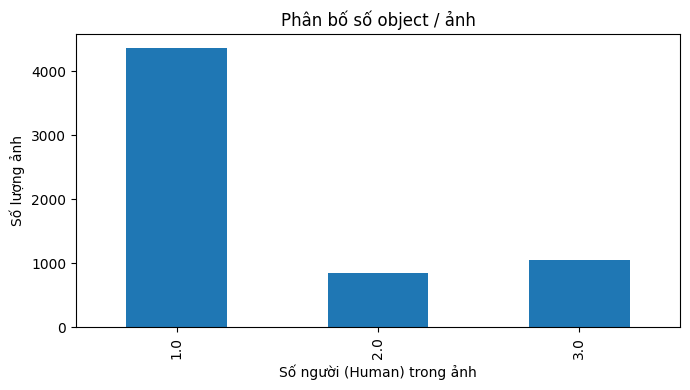

In [3]:
print("Phân bố class:")
print(df["class_name"].value_counts())

valid_counts = box_count.dropna()
print("\nThống kê số object/ảnh:")
print(valid_counts.describe())

fig, ax = plt.subplots(figsize=(7, 4))
valid_counts.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Số người (Human) trong ảnh")
ax.set_ylabel("Số lượng ảnh")
ax.set_title("Phân bố số object / ảnh")
plt.tight_layout()
plt.show()

## 3. Kích thước & tỷ lệ bounding box

Phân tích width/height/area (pixel) và aspect ratio để biết người trong ảnh chủ yếu ở kích cỡ nào - ảnh hưởng đến việc chọn anchor/scale khi train detector.

              w_px         h_px       area_px  aspect_ratio
count  9244.000000  9244.000000   9244.000000   9244.000000
mean     41.474037    98.726633   5232.293596      0.449901
std      22.530009    60.283430   6749.450913      0.173644
min      11.000000    19.000000    392.000000      0.165289
25%      25.750000    61.000000   1564.000000      0.353846
50%      34.000000    77.000000   2516.000000      0.418182
75%      52.000000   111.000000   5712.750000      0.505748
max     202.000000   351.000000  54944.000000      2.950000


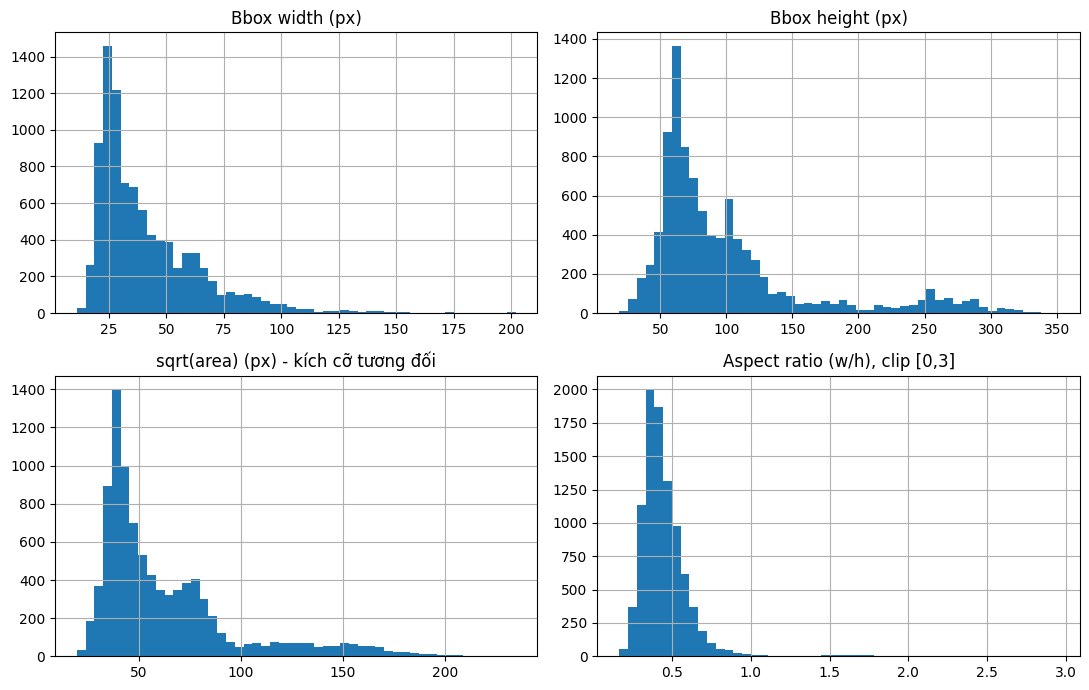

In [4]:
print(df[["w_px", "h_px", "area_px", "aspect_ratio"]].describe())

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
df["w_px"].hist(bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Bbox width (px)")
df["h_px"].hist(bins=50, ax=axes[0, 1])
axes[0, 1].set_title("Bbox height (px)")
np.sqrt(df["area_px"]).hist(bins=50, ax=axes[1, 0])
axes[1, 0].set_title("sqrt(area) (px) - kích cỡ tương đối")
df["aspect_ratio"].clip(0, 3).hist(bins=50, ax=axes[1, 1])
axes[1, 1].set_title("Aspect ratio (w/h), clip [0,3]")
plt.tight_layout()
plt.show()

## 4. Phân bố vị trí bbox trong khung hình

Heatmap tâm bbox (normalized) để xem người thường xuất hiện ở vùng nào của khung hình (center-bias, rìa khung, v.v.).

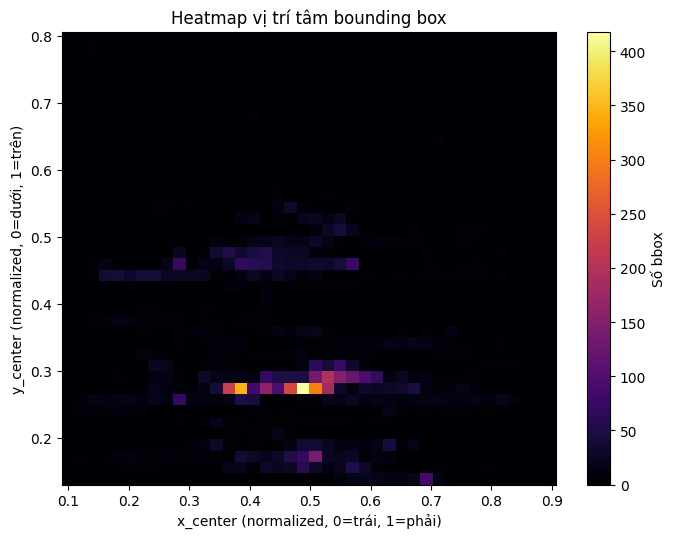

In [5]:
fig, ax = plt.subplots(figsize=(7, 5.5))
h = ax.hist2d(df["xc_norm"], 1 - df["yc_norm"], bins=40, cmap="inferno")
fig.colorbar(h[3], ax=ax, label="Số bbox")
ax.set_xlabel("x_center (normalized, 0=trái, 1=phải)")
ax.set_ylabel("y_center (normalized, 0=dưới, 1=trên)")
ax.set_title("Heatmap vị trí tâm bounding box")
plt.tight_layout()
plt.show()

## 5. Ảnh mẫu kèm bounding box

Chọn ngẫu nhiên vài ảnh có annotation để kiểm tra trực quan bbox có khớp với người trong ảnh không.

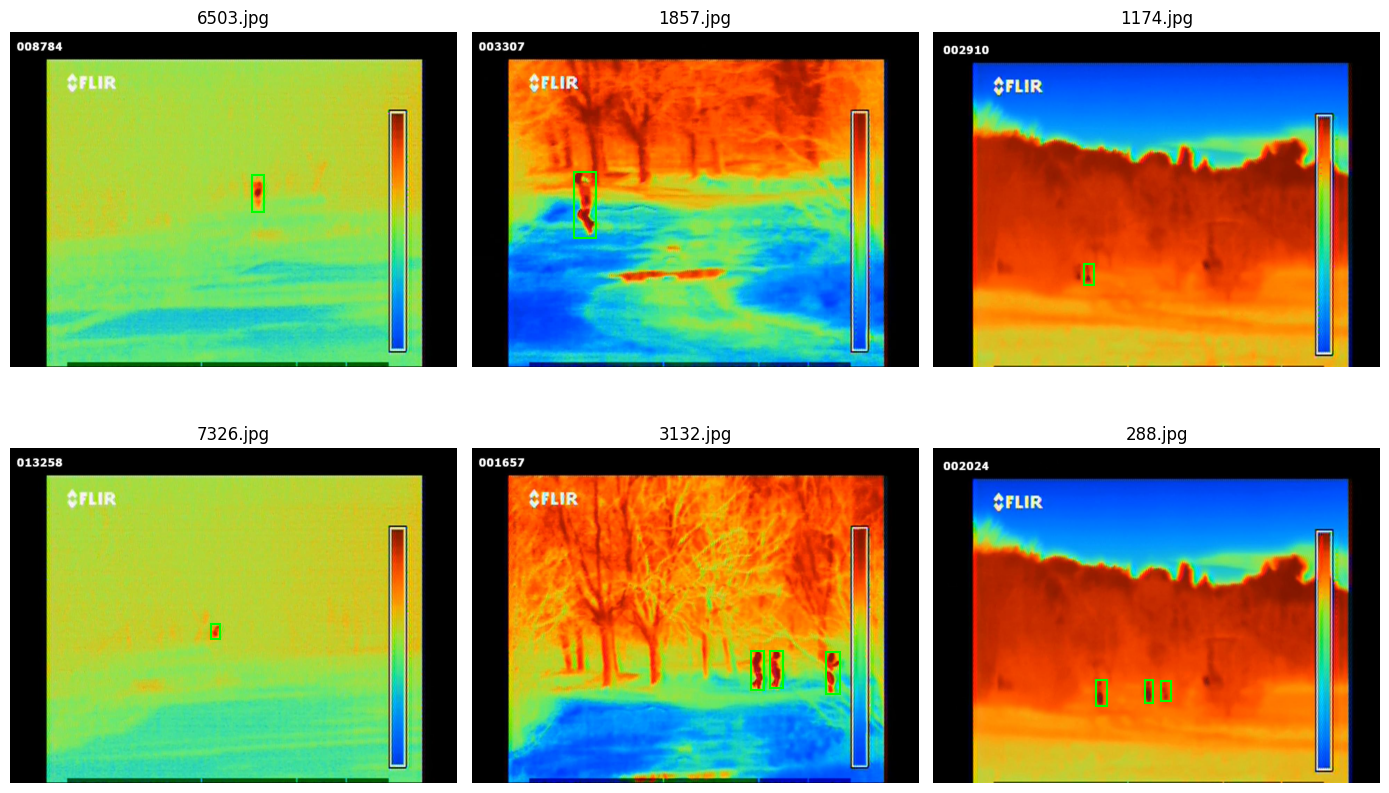

In [6]:
images_with_boxes = valid_counts[valid_counts > 0].index.tolist()
sample_images = random.sample(images_with_boxes, min(6, len(images_with_boxes)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, jpg in zip(axes.flat, sample_images):
    im = Image.open(os.path.join(image_dir, jpg))
    ax.imshow(im)
    boxes = df[df["image"] == jpg]
    for _, b in boxes.iterrows():
        x0 = b["xc_px"] - b["w_px"] / 2
        y0 = b["yc_px"] - b["h_px"] / 2
        ax.add_patch(Rectangle((x0, y0), b["w_px"], b["h_px"],
                                fill=False, edgecolor="lime", linewidth=1.5))
    ax.set_title(jpg)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Phân bố cường độ pixel (đặc trưng ảnh nhiệt)

Ảnh không có timestamp/điều kiện môi trường (xem notebook 01), nhưng độ sáng trung bình của ảnh có thể gợi ý ảnh chụp ban ngày/ban đêm hoặc cảnh nóng/lạnh.

Mẫu: 500 ảnh | Độ sáng trung bình: mean=112.5, std=19.7, min=70.0, max=140.0


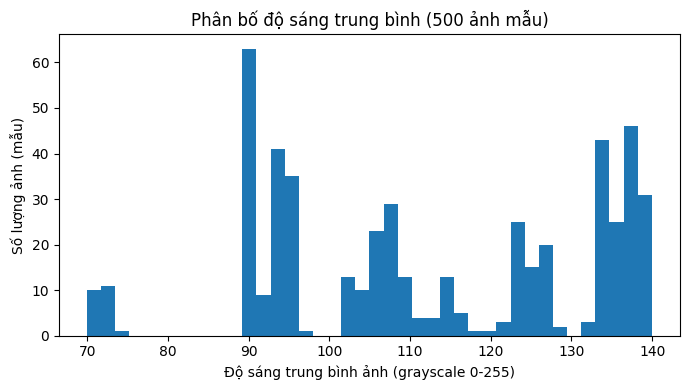

In [7]:
sample_n = min(500, len(jpg_files))
sample_for_intensity = random.sample(jpg_files, sample_n)

mean_brightness = []
for jpg in sample_for_intensity:
    im = Image.open(os.path.join(image_dir, jpg)).convert("L")
    mean_brightness.append(np.array(im).mean())

mean_brightness = np.array(mean_brightness)
print(f"Mẫu: {sample_n} ảnh | Độ sáng trung bình: mean={mean_brightness.mean():.1f}, "
      f"std={mean_brightness.std():.1f}, min={mean_brightness.min():.1f}, max={mean_brightness.max():.1f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(mean_brightness, bins=40)
ax.set_xlabel("Độ sáng trung bình ảnh (grayscale 0-255)")
ax.set_ylabel("Số lượng ảnh (mẫu)")
ax.set_title(f"Phân bố độ sáng trung bình ({sample_n} ảnh mẫu)")
plt.tight_layout()
plt.show()

## 7. Tóm tắt

In [8]:
print("=" * 60)
print("TÓM TẮT EDA")
print("=" * 60)
print(f"Số ảnh: {len(jpg_files)} | Số bbox: {len(df)}")
print(f"Object/ảnh: mean={valid_counts.mean():.2f}, median={valid_counts.median():.0f}, "
      f"max={valid_counts.max():.0f}")
print(f"Bbox area (sqrt): mean={np.sqrt(df['area_px']).mean():.1f}px, "
      f"min={np.sqrt(df['area_px']).min():.1f}px, max={np.sqrt(df['area_px']).max():.1f}px")
print(f"Ảnh không có người (0 box): {(box_count == 0).sum()}")
print(f"Ảnh thiếu annotation (bộ All_In_One): {box_count.isna().sum()}")
print()
print("Lưu ý kế thừa từ notebook 01:")
print("- 202 nhóm ảnh trùng lặp (MD5) vẫn còn trong tập này -> dedupe trước khi split (xem 03_preprocessing.ipynb)")
print("- Dùng bộ annotation All_In_One (không dùng RGB) theo quyết định trong configs/dataset.yaml")
print("- Bbox nhỏ (người ở xa) chiếm tỷ lệ đáng kể -> cần lưu ý augmentation/anchor khi train detector")

TÓM TẮT EDA
Số ảnh: 6340 | Số bbox: 9244
Object/ảnh: mean=1.47, median=1, max=3
Bbox area (sqrt): mean=63.3px, min=19.8px, max=234.4px
Ảnh không có người (0 box): 0
Ảnh thiếu annotation (bộ All_In_One): 64

Lưu ý kế thừa từ notebook 01:
- 202 nhóm ảnh trùng lặp (MD5) vẫn còn trong tập này -> dedupe trước khi split (xem 03_preprocessing.ipynb)
- Dùng bộ annotation All_In_One (không dùng RGB) theo quyết định trong configs/dataset.yaml
- Bbox nhỏ (người ở xa) chiếm tỷ lệ đáng kể -> cần lưu ý augmentation/anchor khi train detector
